# 01 · 标准注意力

> 先从注意力公式开始，手写一个 PyTorch 版本，再测量它的计算时间和显存开销，为理解 FlashAttention 做准备。

**目录**

1. [背景与动机](#1-背景与动机)
2. [数学定义](#2-数学定义)
3. [朴素 PyTorch 实现](#3-朴素-pytorch-实现)
4. [多头注意力](#4-多头注意力)
5. [复杂度分析](#5-复杂度分析)
6. [显存读写分析](#6-显存读写分析)
7. [基准测试](#7-基准测试)
8. [小结](#8-小结)

---

## 1 背景与动机

自注意力是 Transformer 的重要组成部分。它让每个位置按权重汇总其他位置的信息；加上掩码后，只汇总允许关注的位置。不同位置的计算可以并行，也能直接建立远距离位置之间的联系。

```text
输入 X → 线性投影得到 Q、K、V → 注意力计算 → 输出 O
```

这个 Notebook 主要看标准注意力为什么在长序列上占用较多显存。对单个样本、单个头，计算量为 $O(N^2d_k)$，显式保存的分数和权重矩阵占 $O(N^2)$ 空间。只有固定头维度 $d_k$ 时，才能把计算量简写为 $O(N^2)$。FlashAttention 的主要思路是减少中间矩阵的保存和读写。

## 2 数学定义

记序列长度为 $N$，模型维度为 $d_{\text{model}}$，头数为 $h$，每头维度为 $d_k=d_{\text{model}}/h$。本系列默认 value 的维度也等于 $d_k$，批次大小记为 $B$。

先看单个样本、单个头的投影：
$$
Q=XW^Q,\qquad K=XW^K,\qquad V=XW^V.
$$
其中 $X\in\mathbb R^{N\times d_{\text{model}}}$，这一头的 $W^Q,W^K,W^V\in\mathbb R^{d_{\text{model}}\times d_k}$，所以 $Q,K,V\in\mathbb R^{N\times d_k}$。第 4 节的代码会把所有头的投影放在一个 Linear 中，再拆头。

注意力分三步计算：
$$
S=\frac{QK^\top}{\sqrt{d_k}}\in\mathbb R^{N\times N},\qquad
A=\operatorname{softmax}(S)\in\mathbb R^{N\times N},\qquad
O=AV\in\mathbb R^{N\times d_k}.
$$
Softmax 沿每行计算。用 $a,b$ 表示 query、key 的位置：
$$
A_{ab}=\frac{e^{S_{ab}}}{\sum_{u=1}^{N}e^{S_{au}}}.
$$
$A_{ab}$ 表示第 $a$ 个位置分给第 $b$ 个位置的注意力权重。后续分块时，$i,j$ 专门表示块编号。

为什么除以 $\sqrt{d_k}$？如果 query 和 key 的各分量相互独立、均值为 0、方差为 1，则点积的方差为 $d_k$，缩放后约为 1。这说明缩放有助于避免点积过大、softmax 过于集中；训练后的 $Q,K$ 不一定满足这些假设，不能保证方差始终为 1。

2022 论文的算法说明用 $d$ 表示头维度、$P$ 表示权重，并省略了分数缩放。本系列统一使用 $d_k,A$，显式写出 $1/\sqrt{d_k}$；这不改变分块方法和 IO 复杂度分析。

## 3 朴素 PyTorch 实现

In [1]:
import platform
import sys
from IPython import get_ipython

ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")
print(f"运行系统: {platform.system()} {platform.release()}")
print(f"Python: {sys.version.split()[0]}")

import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
results_dir = project_root / "results"
results_dir.mkdir(exist_ok=True)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

运行系统: Linux 6.6.87.2-microsoft-standard-WSL2
Python: 3.10.12


PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


### 3.1 手写 `simple_attention`

先按公式计算分数、权重和输出。本例布尔掩码中的 `True` 表示遮蔽，并假设每行至少有一个可见 key。Dropout 由 `training` 参数控制；训练模式与是否记录梯度是两回事。

In [2]:
def simple_attention(
    Q: torch.Tensor,  # (B, N, d_k)
    K: torch.Tensor,
    V: torch.Tensor,
    mask: torch.Tensor | None = None,
    dropout_p: float = 0.0,
    training: bool = True,
) -> tuple[torch.Tensor, torch.Tensor]:
    
    d_k = Q.size(-1)

    # 计算 logits，shape (B, N, N)
    scores = torch.bmm(Q, K.transpose(-2, -1)) / math.sqrt(d_k)

    # 可选掩码（因果掩码或 padding 掩码）
    if mask is not None:
        # mask 中 True 的位置被遮蔽（填 -inf）
        scores = scores.masked_fill(mask, float("-inf"))

    # Softmax → 注意力权重
    attn = torch.softmax(scores, dim=-1)  # (B, N, N)

    # Dropout（训练时）
    if dropout_p > 0.0:
        attn = F.dropout(attn, p=dropout_p, training=training)

    # 加权求和
    output = torch.bmm(attn, V)  # (B, N, d_k)，也支持 V 的最后一维与 d_k 不同

    return output, attn

### 3.2 验证一下：与 PyTorch 内置算法对比

In [3]:
torch.manual_seed(42)

B, N, d_k = 2, 64, 64  # batch=2, seq_len=64, head_dim=64
device = "cuda" if torch.cuda.is_available() else "cpu"

Q = torch.randn(B, N, d_k, device=device)
K = torch.randn(B, N, d_k, device=device)
V = torch.randn(B, N, d_k, device=device)

# 我的实现
out_naive, attn_weights = simple_attention(Q, K, V)

# PyTorch 内置
# 使用显式的头维度 (B, h, N, d_k)；SDPA 并不只接受四维输入
out_torch = F.scaled_dot_product_attention(
    Q.unsqueeze(1), K.unsqueeze(1), V.unsqueeze(1)
).squeeze(1)

max_diff = (out_naive - out_torch).abs().max().item()
print(f"输出最大绝对误差: {max_diff:.2e}")
assert max_diff < 1e-4, f"误差过大！{max_diff}"
print("simple_attention 与自动 SDPA 在上述容差内一致")

输出最大绝对误差: 1.25e-06
simple_attention 与自动 SDPA 在上述容差内一致


### 3.3 因果掩码

解码器自注意力允许每个 token 关注自己及左侧的 token，遮蔽右侧的未来位置。因此下面只遮蔽主对角线上方。

这里 `True` 表示遮蔽；SDPA 的布尔 `attn_mask` 则用 `True` 表示允许关注，两种接口之间传递掩码时要取反。

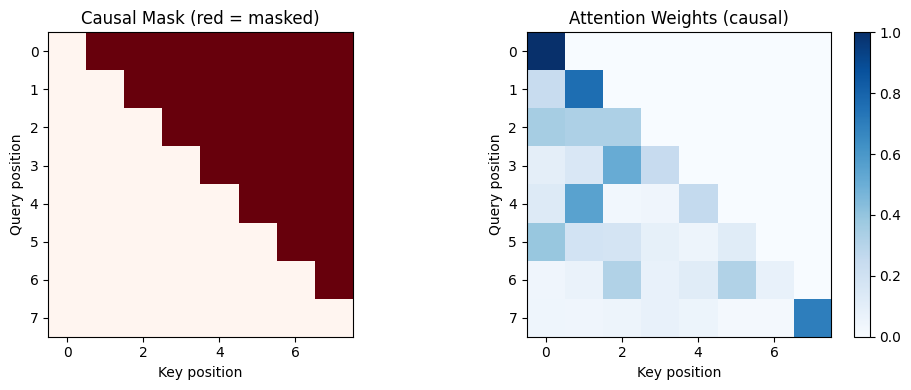

图像已保存至 results/01_causal_mask.png


In [4]:
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams["font.family"] = ["DejaVu Sans", "sans-serif"]

def make_causal_mask(seq_len: int, device: torch.device) -> torch.Tensor:
    """返回上三角布尔掩码，True 表示被遮蔽（未来位置）。"""
    # torch.triu 取上三角，diagonal=1 表示主对角线上方
    return torch.triu(torch.ones(seq_len, seq_len, device=device, dtype=torch.bool), diagonal=1)

N_vis = 8
causal_mask = make_causal_mask(N_vis, device="cpu")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# 掩码可视化
axes[0].imshow(causal_mask.float().numpy(), cmap="Reds", vmin=0, vmax=1)
axes[0].set_title("Causal Mask (red = masked)")
axes[0].set_xlabel("Key position")
axes[0].set_ylabel("Query position")

# 注意力权重可视化（应用因果掩码后）
torch.manual_seed(0)
Q_vis = torch.randn(1, N_vis, 16)
K_vis = torch.randn(1, N_vis, 16)
V_vis = torch.randn(1, N_vis, 16)
_, attn_vis = simple_attention(Q_vis, K_vis, V_vis, mask=causal_mask.unsqueeze(0))

im = axes[1].imshow(attn_vis[0].detach().numpy(), cmap="Blues", vmin=0)
axes[1].set_title("Attention Weights (causal)")
axes[1].set_xlabel("Key position")
axes[1].set_ylabel("Query position")
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.savefig(results_dir / "01_causal_mask.png", dpi=120, bbox_inches="tight")
plt.show()
print("图像已保存至 results/01_causal_mask.png")

## 4 多头注意力

每个头都有自己的投影参数，得到不同的 $Q,K,V$，分别计算注意力，再拼接输出：
$$
\operatorname{MHA}(X)=\operatorname{Concat}(\operatorname{head}_1,\ldots,\operatorname{head}_h)W^O,
$$
$$
\operatorname{head}_r=\operatorname{Attention}(XW^Q_r,XW^K_r,XW^V_r),\qquad
W^O\in\mathbb R^{hd_k\times d_{\text{model}}}.
$$
代码中先做线性投影，再把结果拆成 $h$ 个头。每个头可以学到不同的关系，但不能保证它们一定学到互不相同的模式。

In [5]:
class MultiHeadAttention(nn.Module):
    """
    多头自注意力，使用 simple_attention 作为单头实现。
    输入形状：(B, N, d_model)
    """

    def __init__(self, d_model: int, num_heads: int, dropout: float = 0.0):
        super().__init__()
        assert d_model % num_heads == 0, "d_model 必须能被 num_heads 整除"
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        self.dropout = dropout

        # 线性投影层（将 d_model → d_model，内含所有头的参数）
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)

    def _split_heads(self, x: torch.Tensor) -> torch.Tensor:
        """(B, N, d_model) → (B*h, N, d_k)，将多头展开为 batch 维。"""
        B, N, _ = x.shape
        # (B, N, h, d_k) → (B, h, N, d_k) → (B*h, N, d_k)
        x = x.view(B, N, self.num_heads, self.d_k)
        x = x.permute(0, 2, 1, 3).contiguous()
        return x.view(B * self.num_heads, N, self.d_k)

    def _merge_heads(self, x: torch.Tensor, B: int) -> torch.Tensor:
        """(B*h, N, d_k) → (B, N, d_model)。"""
        _, N, _ = x.shape
        x = x.view(B, self.num_heads, N, self.d_k)
        x = x.permute(0, 2, 1, 3).contiguous()
        return x.view(B, N, self.d_model)

    def forward(
        self,
        x: torch.Tensor,  # (B, N, d_model)
        mask: torch.Tensor | None = None,  # (B, N, N) 或 None
    ) -> torch.Tensor:
        B = x.size(0)

        # 投影 + 拆分多头
        Q = self._split_heads(self.W_Q(x))  # (B*h, N, d_k)
        K = self._split_heads(self.W_K(x))
        V = self._split_heads(self.W_V(x))

        # 将掩码广播到所有头
        head_mask = None
        if mask is not None:
            # mask: (B, N, N) → (B*h, N, N)
            head_mask = mask.unsqueeze(1).expand(-1, self.num_heads, -1, -1)
            head_mask = head_mask.reshape(B * self.num_heads, mask.size(-2), mask.size(-1))

        # 注意力计算
        output, _ = simple_attention(
            Q, K, V, mask=head_mask, dropout_p=self.dropout, training=self.training
        )

        # 合并多头 + 输出投影
        output = self._merge_heads(output, B)   # (B, N, d_model)
        output = self.W_O(output)
        return output

In [6]:
# 快速功能验证
torch.manual_seed(0)
B, N, d_model, num_heads = 4, 128, 256, 8
mha = MultiHeadAttention(d_model, num_heads).to(device)
x = torch.randn(B, N, d_model, device=device)

out = mha(x)
print(f"MHA 输入形状: {x.shape}")
print(f"MHA 输出形状: {out.shape}")
assert out.shape == (B, N, d_model)
print("MultiHeadAttention 形状正确")

# 与 PyTorch 官方 MHA 对比（相同权重）
mha_ref = nn.MultiheadAttention(
    d_model, num_heads, dropout=0.0, bias=False, batch_first=True
).to(device)

# 将权重复制到参考实现
with torch.no_grad():
    mha_ref.in_proj_weight.copy_(
        torch.cat([mha.W_Q.weight, mha.W_K.weight, mha.W_V.weight], dim=0)
    )
    mha_ref.out_proj.weight.copy_(mha.W_O.weight)

out_ref, _ = mha_ref(x, x, x, need_weights=False)
max_diff = (out - out_ref).abs().max().item()
print(f"与 nn.MultiheadAttention 最大绝对误差: {max_diff:.2e}")

MHA 输入形状: torch.Size([4, 128, 256])
MHA 输出形状: torch.Size([4, 128, 256])
MultiHeadAttention 形状正确


与 nn.MultiheadAttention 最大绝对误差: 1.04e-07


## 5 复杂度分析

### 5.1 计算量

先看单个样本、单个头，不计投影层、掩码和 dropout。按一次乘法和一次加法共 2 FLOPs 估算：

| 步骤 | 操作 | 计算量 |
|------|------|--------|
| $QK^\top$ | $(N,d_k)\times(d_k,N)$ | 约 $2N^2d_k$ FLOPs |
| Softmax | 沿每行求最大值、指数和分母 | $\Theta(N^2)$ |
| $AV$ | $(N,N)\times(N,d_k)$ | 约 $2N^2d_k$ FLOPs |

两次矩阵乘合计约 $4BhN^2d_k=4BN^2d_{\text{model}}$ FLOPs，总计算量为 $\Theta(BhN^2d_k)$。完整 MHA 还包括四个线性投影，其计算量为 $O(BNd_{\text{model}}^2)$，不能把上面的估算当作整层的全部开销。

### 5.2 中间矩阵占多少显存？

朴素实现显式生成 $S,A$，它们的形状都是 $(B,h,N,N)$。只算一个 FP32 权重矩阵 $A$：
$$
\operatorname{Memory}(A)=BhN^2\times4\ \text{bytes}.
$$
例如 $B=1,h=16,N=4096$ 时：
$$
1\times16\times4096^2\times4=1{,}073{,}741{,}824\ \text{bytes}
=1\ \text{GiB}\approx1.074\ \text{GB}.
$$
这只是一个矩阵的数据量。输入、输出、其他临时张量和反向传播保存的状态还会继续占用显存。下面的曲线用十进制 GB，画的也只是 $A$ 的数据量。

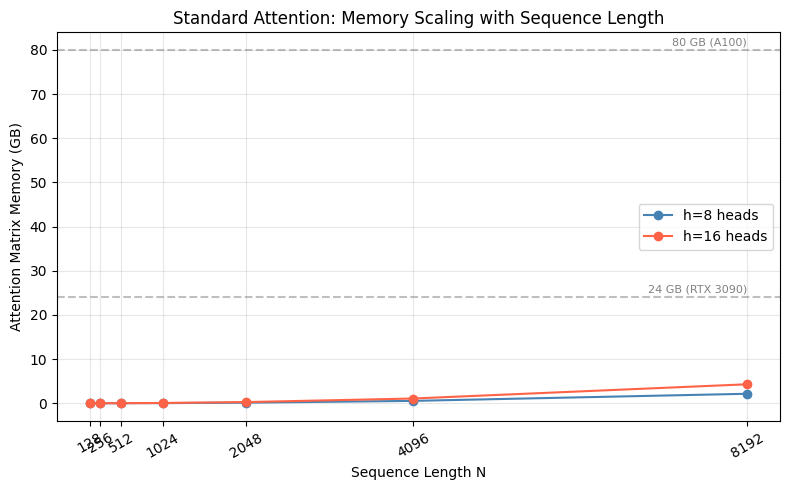

图像已保存至 results/01_memory_scaling.png


In [7]:
import numpy as np

# 可视化注意力矩阵显存随序列长度的增长
seq_lens = [128, 256, 512, 1024, 2048, 4096, 8192]
num_heads_list = [8, 16]
batch_size = 1
bytes_per_float32 = 4

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["steelblue", "tomato"]

for color, h in zip(colors, num_heads_list):
    mem_gb = [
        batch_size * h * (N ** 2) * bytes_per_float32 / 1e9
        for N in seq_lens
    ]
    ax.plot(seq_lens, mem_gb, marker="o", color=color, label=f"h={h} heads")

# 标注常见 GPU 显存线
for mem, label in [(24, "24 GB (RTX 3090)"), (80, "80 GB (A100)")]:
    ax.axhline(mem, linestyle="--", alpha=0.5, color="gray")
    ax.text(seq_lens[-1], mem + 1, label, ha="right", fontsize=8, color="gray")

ax.set_xlabel("Sequence Length N")
ax.set_ylabel("Attention Matrix Memory (GB)")
ax.set_title("Standard Attention: Memory Scaling with Sequence Length")
ax.set_xticks(seq_lens)
ax.set_xticklabels([str(n) for n in seq_lens], rotation=30)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(results_dir / "01_memory_scaling.png", dpi=120, bbox_inches="tight")
plt.show()
print("图像已保存至 results/01_memory_scaling.png")

## 6 显存读写分析

注意力的两次矩阵乘需要计算，softmax 等步骤还要读写很多数据。2022 论文以 HBM（高带宽显存）和 SRAM（片上高速存储）为例，说明减少数据搬运也能加速。不同 GPU 的显存类型可能不同，例如本项目所用的 RTX 4060 Laptop 使用 GDDR6（[NVIDIA 规格](https://www.nvidia.com/en-us/geforce/laptops/40-series/)）；下文沿用论文的 HBM 名称来讨论 IO 模型。

先按各步骤的输入、输出估算单样本、单头的读写元素数，不计矩阵乘内部的重复读取：

| 阶段 | 读 | 写 |
|------|----|----|
| $S=QK^\top/\sqrt{d_k}$ | $2Nd_k$ | $N^2$ |
| $A=\operatorname{softmax}(S)$ | $N^2$ | $N^2$ |
| $O=AV$ | $N^2+Nd_k$ | $Nd_k$ |
| 合计 | $2N^2+3Nd_k$ | $2N^2+Nd_k$ |

总量为 $\Theta(Nd_k+N^2)$。字节数还要乘上每个元素占用的字节数。当 $N\gg d_k$ 时，完整 $S,A$ 的读写占主要部分。

FlashAttention 只在片上计算当前分数块和指数块，更新输出后就丢弃这些中间块，不把完整 $S,A$ 写入 HBM。若 SRAM 可容纳 $M$ 个元素，总访问量为
$$
\Theta\!\left(Nd_k+\frac{N^2d_k^2}{M}\right).
$$
论文 Theorem 2 在 $d_k\le M\le Nd_k$ 的范围内将它写为 $\Theta(N^2d_k^2/M)$。注意这里是 $d_k^2$，而且 $M$ 的单位是元素数，不能直接代入字节数。

下面只画省略常数后的数量级示意，没有测量实际 HBM 流量，也不能用曲线比例直接推断加速比。第 03 节会展开推导。

来源：[FlashAttention 本地论文，第 5 页 Theorem 2](https://arxiv.org/abs/2205.14135)。

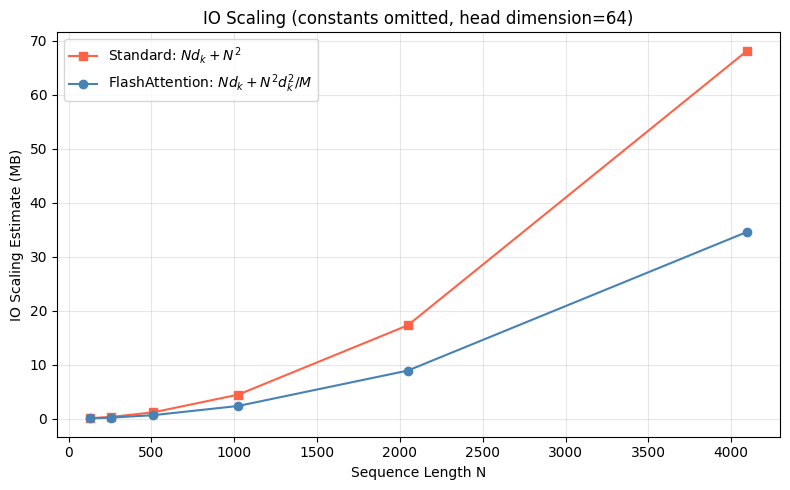

图像已保存至 results/01_hbm_access.png


In [8]:
# IO 数量级示意：省略常数，不是硬件流量实测
seq_lens_hbm = [128, 256, 512, 1024, 2048, 4096]
d_k_val = 64
M_sram = 8_192  # 可容纳的元素数；这些 N 均满足 d_k <= M_sram <= N*d_k
bytes_per_element = 4  # 用 FP32 字节数换算示意曲线

standard_hbm = [
    (N * d_k_val + N**2) * bytes_per_element / 1e6
    for N in seq_lens_hbm
]
flash_hbm = [
    (N * d_k_val + N**2 * d_k_val**2 / M_sram) * bytes_per_element / 1e6
    for N in seq_lens_hbm
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(seq_lens_hbm, standard_hbm, marker="s", label=r"Standard: $Nd_k+N^2$", color="tomato")
ax.plot(seq_lens_hbm, flash_hbm, marker="o", label=r"FlashAttention: $Nd_k+N^2d_k^2/M$", color="steelblue")
ax.set_xlabel("Sequence Length N")
ax.set_ylabel("IO Scaling Estimate (MB)")
ax.set_title(f"IO Scaling (constants omitted, head dimension={d_k_val})")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(results_dir / "01_hbm_access.png", dpi=120, bbox_inches="tight")
plt.show()
print("图像已保存至 results/01_hbm_access.png")

## 7 基准测试

使用相同的 FP32 输入，比较手写实现和自动 SDPA，只测关闭梯度、关闭 dropout 的单头前向。自动 SDPA 的具体 backend 取决于设备和输入，不能把它直接叫作 FlashAttention。

`torch.utils.benchmark` 会处理 CUDA 同步，下面预热后测 20 次调用的平均延迟。显存记录一次调用新增的峰值已分配量：峰值减去调用前的已分配量，包含输出和临时张量，不包含已经存在的输入。CPU 的 CUDA 显存记为 `null`。

后面的 Notebook 使用的头数、数据类型和测量范围可能不同，跨 Notebook 比较前还需要核对这些设置。

In [9]:
import torch.utils.benchmark as benchmark
import json

@torch.no_grad()
def measure_latency_and_memory(
    fn, *args, label: str = "", n_warmup: int = 5, n_repeat: int = 20,
) -> dict:
    """测量前向平均延迟（ms）和调用新增的峰值显存（MB）。"""
    dev = args[0].device
    for _ in range(n_warmup):
        fn(*args)
    if dev.type == "cuda":
        torch.cuda.synchronize(dev)
        baseline = torch.cuda.memory_allocated(dev)
        torch.cuda.reset_peak_memory_stats(dev)
        output = fn(*args)
        torch.cuda.synchronize(dev)
        mem_mb = (torch.cuda.max_memory_allocated(dev) - baseline) / 1e6
        del output
    else:
        mem_mb = None
    timing = benchmark.Timer(
        stmt="fn(*args)", globals={"fn": fn, "args": args}, label=label, num_threads=1,
    ).timeit(n_repeat)
    return dict(label=label, status="ok", latency_ms=timing.mean * 1e3,
                timing_iterations=n_repeat, memory_mb=mem_mb,
                memory_metric="incremental_peak_allocated")

In [10]:
BENCH_SEQ_LENS = [128, 256, 512, 1024]
if torch.cuda.is_available():
    BENCH_SEQ_LENS += [2048, 4096]
BENCH_D_K, BENCH_BATCH, BENCH_DEVICE = 64, 1, device

def run_naive(Q, K, V):
    return simple_attention(Q, K, V)[0]

def run_torch_sdpa(Q, K, V):
    # 显式补出单头维度，以 (B,h,N,d_k) 形式调用。
    return F.scaled_dot_product_attention(
        Q.unsqueeze(1), K.unsqueeze(1), V.unsqueeze(1), dropout_p=0.0
    ).squeeze(1)

records = []
for N in BENCH_SEQ_LENS:
    torch.manual_seed(0)
    Q = torch.randn(BENCH_BATCH, N, BENCH_D_K, device=BENCH_DEVICE, dtype=torch.float32)
    K, V = torch.randn_like(Q), torch.randn_like(Q)
    for impl, fn in [("simple_attention", run_naive), ("F.sdpa (auto)", run_torch_sdpa)]:
        metadata = dict(impl=impl, seq_len=N, batch=BENCH_BATCH, heads=1, d_k=BENCH_D_K,
                        dtype=str(Q.dtype), device=str(Q.device), causal=False,
                        torch_version=torch.__version__)
        try:
            row = dict(**metadata, **measure_latency_and_memory(fn, Q, K, V, label=impl))
        except torch.cuda.OutOfMemoryError:
            row = dict(**metadata, status="oom", latency_ms=None, memory_mb=None)
            torch.cuda.empty_cache()
        records.append(row)
        print(row)
    del Q, K, V

with open(results_dir / "01_benchmark_standard_attention.json", "w", encoding="utf-8") as f:
    json.dump(records, f, indent=2, ensure_ascii=False, allow_nan=False)
print("基准结果已保存至 results/01_benchmark_standard_attention.json")

{'impl': 'simple_attention', 'seq_len': 128, 'batch': 1, 'heads': 1, 'd_k': 64, 'dtype': 'torch.float32', 'device': 'cuda:0', 'causal': False, 'torch_version': '2.11.0+cu128', 'label': 'simple_attention', 'status': 'ok', 'latency_ms': 2.4448456999998314, 'timing_iterations': 20, 'memory_mb': 0.16384, 'memory_metric': 'incremental_peak_allocated'}
{'impl': 'F.sdpa (auto)', 'seq_len': 128, 'batch': 1, 'heads': 1, 'd_k': 64, 'dtype': 'torch.float32', 'device': 'cuda:0', 'causal': False, 'torch_version': '2.11.0+cu128', 'label': 'F.sdpa (auto)', 'status': 'ok', 'latency_ms': 2.657217499999831, 'timing_iterations': 20, 'memory_mb': 0.032768, 'memory_metric': 'incremental_peak_allocated'}


{'impl': 'simple_attention', 'seq_len': 256, 'batch': 1, 'heads': 1, 'd_k': 64, 'dtype': 'torch.float32', 'device': 'cuda:0', 'causal': False, 'torch_version': '2.11.0+cu128', 'label': 'simple_attention', 'status': 'ok', 'latency_ms': 2.440520799999746, 'timing_iterations': 20, 'memory_mb': 0.589824, 'memory_metric': 'incremental_peak_allocated'}


{'impl': 'F.sdpa (auto)', 'seq_len': 256, 'batch': 1, 'heads': 1, 'd_k': 64, 'dtype': 'torch.float32', 'device': 'cuda:0', 'causal': False, 'torch_version': '2.11.0+cu128', 'label': 'F.sdpa (auto)', 'status': 'ok', 'latency_ms': 14.01401724999971, 'timing_iterations': 20, 'memory_mb': 0.065536, 'memory_metric': 'incremental_peak_allocated'}


{'impl': 'simple_attention', 'seq_len': 512, 'batch': 1, 'heads': 1, 'd_k': 64, 'dtype': 'torch.float32', 'device': 'cuda:0', 'causal': False, 'torch_version': '2.11.0+cu128', 'label': 'simple_attention', 'status': 'ok', 'latency_ms': 9.063269600000012, 'timing_iterations': 20, 'memory_mb': 2.228224, 'memory_metric': 'incremental_peak_allocated'}


{'impl': 'F.sdpa (auto)', 'seq_len': 512, 'batch': 1, 'heads': 1, 'd_k': 64, 'dtype': 'torch.float32', 'device': 'cuda:0', 'causal': False, 'torch_version': '2.11.0+cu128', 'label': 'F.sdpa (auto)', 'status': 'ok', 'latency_ms': 11.723955249999563, 'timing_iterations': 20, 'memory_mb': 0.131072, 'memory_metric': 'incremental_peak_allocated'}


...

{'impl': 'F.sdpa (auto)', 'seq_len': 1024, 'batch': 1, 'heads': 1, 'd_k': 64, 'dtype': 'torch.float32', 'device': 'cuda:0', 'causal': False, 'torch_version': '2.11.0+cu128', 'label': 'F.sdpa (auto)', 'status': 'ok', 'latency_ms': 12.860636950000526, 'timing_iterations': 20, 'memory_mb': 0.262144, 'memory_metric': 'incremental_peak_allocated'}


{'impl': 'simple_attention', 'seq_len': 2048, 'batch': 1, 'heads': 1, 'd_k': 64, 'dtype': 'torch.float32', 'device': 'cuda:0', 'causal': False, 'torch_version': '2.11.0+cu128', 'label': 'simple_attention', 'status': 'ok', 'latency_ms': 33.33287889999994, 'timing_iterations': 20, 'memory_mb': 34.07872, 'memory_metric': 'incremental_peak_allocated'}


{'impl': 'F.sdpa (auto)', 'seq_len': 2048, 'batch': 1, 'heads': 1, 'd_k': 64, 'dtype': 'torch.float32', 'device': 'cuda:0', 'causal': False, 'torch_version': '2.11.0+cu128', 'label': 'F.sdpa (auto)', 'status': 'ok', 'latency_ms': 141.9389951499994, 'timing_iterations': 20, 'memory_mb': 0.524288, 'memory_metric': 'incremental_peak_allocated'}


{'impl': 'simple_attention', 'seq_len': 4096, 'batch': 1, 'heads': 1, 'd_k': 64, 'dtype': 'torch.float32', 'device': 'cuda:0', 'causal': False, 'torch_version': '2.11.0+cu128', 'label': 'simple_attention', 'status': 'ok', 'latency_ms': 915.0843791499994, 'timing_iterations': 20, 'memory_mb': 135.266304, 'memory_metric': 'incremental_peak_allocated'}


{'impl': 'F.sdpa (auto)', 'seq_len': 4096, 'batch': 1, 'heads': 1, 'd_k': 64, 'dtype': 'torch.float32', 'device': 'cuda:0', 'causal': False, 'torch_version': '2.11.0+cu128', 'label': 'F.sdpa (auto)', 'status': 'ok', 'latency_ms': 695.3891891499993, 'timing_iterations': 20, 'memory_mb': 1.048576, 'memory_metric': 'incremental_peak_allocated'}
基准结果已保存至 results/01_benchmark_standard_attention.json


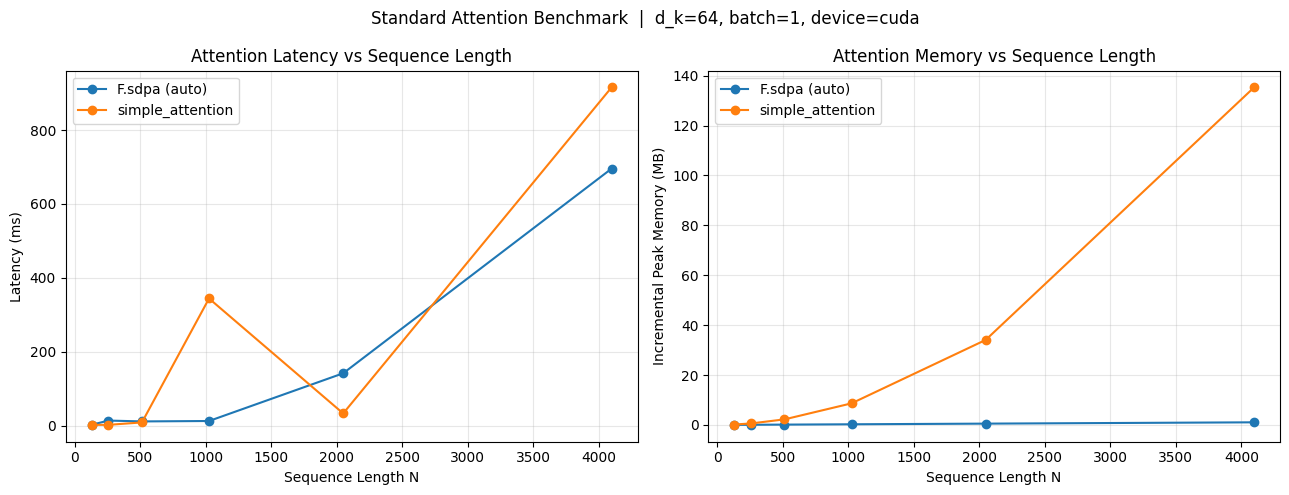

图像已保存至 results/01_benchmark_plot.png


In [11]:
# 绘制延迟对比图
import pandas as pd

df = pd.DataFrame([row for row in records if row["status"] == "ok"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric, ylabel, title in [
    (axes[0], "latency_ms", "Latency (ms)", "Attention Latency vs Sequence Length"),
    (axes[1], "memory_mb",  "Incremental Peak Memory (MB)", "Attention Memory vs Sequence Length"),
]:
    for impl, grp in df.groupby("impl"):
        grp_sorted = grp.dropna(subset=[metric]).sort_values("seq_len")
        if grp_sorted.empty:
            continue
        ax.plot(
            grp_sorted["seq_len"],
            grp_sorted[metric],
            marker="o",
            label=impl,
        )
    ax.set_xlabel("Sequence Length N")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    if ax.lines:
        ax.legend()
    elif metric == "memory_mb":
        ax.text(0.5, 0.5, "CUDA memory is not measured on CPU",
                ha="center", transform=ax.transAxes)
    ax.grid(alpha=0.3)

plt.suptitle(f"Standard Attention Benchmark  |  d_k={BENCH_D_K}, batch={BENCH_BATCH}, device={BENCH_DEVICE}")
plt.tight_layout()
plt.savefig(results_dir / "01_benchmark_plot.png", dpi=120, bbox_inches="tight")
plt.show()
print("图像已保存至 results/01_benchmark_plot.png")

## 8 小结

手写标准注意力需要显式生成 $N\times N$ 的分数和权重矩阵。固定头维度时，它的计算量和这些中间矩阵的存储量都随 $N^2$ 增长。

上面的实测用来观察本机的前向延迟和新增峰值显存。延迟还受算子实现、并行度和调用开销影响，不能仅凭理论计算量就断言耗时严格按 $N^2$ 增长；自动 SDPA 的 backend 也需要另外确认。这里没有测量带宽利用率，因此不能把所有设置下的瓶颈都归结为显存读写。

论文给出的方向是分块计算：保留输出和每行的统计量，用完当前分数块后就丢弃它。这样仍能计算相同的注意力，同时减少大矩阵的保存和读写。接下来在 [02 · Online Softmax](02_online_softmax.ipynb) 中，先理解分母为什么可以边计算边更新。

**参考文献**

- [FlashAttention，NeurIPS 2022，本地 PDF](https://arxiv.org/abs/2205.14135)
- [PyTorch SDPA 文档](https://docs.pytorch.org/docs/2.11/generated/torch.nn.functional.scaled_dot_product_attention.html)